# NEOFC - Application in HCP-Early Psychosis data

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sn
import seaborn.objects as so
import warnings
import seaborn as sn
import seaborn.objects as so
import statsmodels.formula.api as smf
import pingouin as pg
import pickle
import gzip
from nispace.stats.misc import residuals
from nispace.stats.coloc import pearson
from nilearn.plotting import plot_surf_contours, plot_surf_stat_map, plot_stat_map
from neuromaps.datasets import fetch_fslr
from neuromaps.images import load_gifti, load_nifti
from nilearn.connectome import vec_to_sym_matrix
from nispace.utils.utils import vect_to_vol_arr

from utils import load_neofc_stats, load_sac_gc, meff_li_ji, sidak

# working directory
wd = Path.cwd() 
print(wd)

# general vars
from utils import (REF_GROUPS, REF_GROUPS_COLORS, REF_GROUPNAMES_PET, REF_NAMES_PET, REF_GROUPS_PET,
                   PARC_DEFAULT, PARCS_ALL, PARCS_CX, 
                   MEASURES_ALL, MEASURES_NICE, MEG_MEASURES_ALL, MEG_FQBANDS, REF_MATH_NAMES,
                   REF_COLORS_BY_MAP)

/Users/llotter/projects/mapfc


## Data

In [2]:
parc_cx = "Schaefer200"
parc_wb = "Schaefer200Subcortical"
parcs = [parc_cx, parc_wb]

### Mapconn stats: HCP-EP

In [3]:
mfc_ep_groupstats, mfc_ep_indivstats = load_neofc_stats("hcp_ep", index_special="dx", stats="auc")
#display(mfc_ep_groupstats.head(), mfc_ep_indivstats.head())

Loading group stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ep/parc-..._stat-..._group.csv.gz
Loading individual stats: /Users/llotter/projects/mapfc/results/neofc/hcp_ep/parc-..._stat-..._individual.csv.gz


### HCP-EP pheno

In [4]:
pheno_ep = pd.read_csv(wd / "data_deriv" / "pheno" / "hcp_ep" / "hcpep_pheno.csv", index_col=0)
#pheno_ep

### QC

In [5]:
qc_ep = pd.read_csv(wd / "data_deriv" / "pheno" / "hcp_ep" / "hcpep_qc.csv", index_col=0)
#qc_ep

### Global connectivity and autocorrelation

In [6]:
sac_ep = load_sac_gc("hcp_ep", index_special="dx")
#sac_ep

### Merged dataframe

In [7]:
# merged dataframe
df_ep_merged = (
    mfc_ep_indivstats
    .loc[:, "pearson", "all", :, ["original", "inverted"], "auc", "val"]
    .rename_axis(index={"id": "sub"})
    .merge(qc_ep, left_on="sub", right_index=True, how="left") # merge with qc
    .merge(sac_ep, left_on=["parc", "measure", "dx", "sub"], right_index=True, how="left") # merge with sac/gc
    .merge(pheno_ep, left_on="sub", right_index=True, how="left") # merge with pheno
    .query("qc_pass") # restrict to subjects passing QC
    .droplevel(["measure", "connections", "stat", "variable", "dx"]) # drop levels with only one value, and dx with is also a column
)

# new category names
psy_grouplabels = {
    "CTRL": "CTRL",
    "SCZ": "PSY",
    "SCA": "aPSY",
    "SCZ_noapd": "PSY_noAPD",
    "SCZ_apd": "PSY_APD"
}

# dx variables to categorical
df_ep_merged["dx"] = pd.Categorical(df_ep_merged["dx"], categories=["CTRL", "SCZ"], ordered=True).rename_categories(psy_grouplabels)
df_ep_merged["dx_sub"] = pd.Categorical(df_ep_merged["dx_sub"], categories=["CTRL", "SCZ", "SCA"], ordered=True).rename_categories(psy_grouplabels)
df_ep_merged["dx_apd_lifetime"] = pd.Categorical(df_ep_merged["dx_apd_lifetime"], categories=["CTRL", "SCZ_noapd", "SCZ_apd"], ordered=True).rename_categories(psy_grouplabels)
df_ep_merged["dx_apd_current"] = pd.Categorical(df_ep_merged["dx_apd_current"], categories=["CTRL", "SCZ_noapd", "SCZ_apd"], ordered=True).rename_categories(psy_grouplabels)

# simple check if everything is ok
# (if sth went wrong during merging, we'd have duplicated values for an indexer like this)
assert df_ep_merged.loc[parc_cx, "original", :]["NET"].duplicated().sum() == 0

# quick overview
for dx in ["dx", "dx_sub"]:
    print(df_ep_merged.loc[parc_cx, "original", :].groupby(dx, observed=True)["age"].describe())
    print(df_ep_merged.loc[parc_cx, "original", :].groupby(dx, observed=True)["sex"].value_counts())

#df_ep_merged

      count       mean       std    min    25%    50%     75%    max
dx                                                                  
CTRL   55.0  24.818364  4.073707  16.83  21.71  24.42  26.210  35.67
PSY    96.0  22.658854  3.617435  16.67  19.98  22.04  24.435  34.83
dx    sex
CTRL  M      36
      F      19
PSY   M      56
      F      40
Name: count, dtype: int64
        count       mean       std    min    25%    50%     75%    max
dx_sub                                                                
CTRL     55.0  24.818364  4.073707  16.83  21.71  24.42  26.210  35.67
PSY      71.0  22.038732  3.104509  16.67  19.75  21.42  23.795  30.75
aPSY     25.0  24.420000  4.395321  17.58  21.25  24.00  26.330  34.83
dx_sub  sex
CTRL    M      36
        F      19
PSY     M      48
        F      23
aPSY    F      17
        M       8
Name: count, dtype: int64


## Harmonize MapConn data

In [8]:
from neuroHarmonize import harmonizationLearn, harmonizationApply

# dataframe with harmonized data, we will use this for all analyses
df_ep = df_ep_merged.copy(deep=True)

# iterate over parcs, metrics, stats
for parc in parcs:
    for metric in ["original", "inverted"]:
        
        # get data
        df = df_ep_merged.loc[parc, metric, :].copy()
        
        # target data to harmonize
        df_data = df[REF_NAMES_PET]
        
        # covariates to remove (SITE) and retain (sex, age, mean_fd, gc)
        df_covs = (
            df[["site", "sex_num", "age", "mean_fd", "gc"]] \
            .rename(columns={"site": "SITE"}) \
        )
        
        # get subjects
        subs_ctrl = df[df.dx == "CTRL"].index.get_level_values("sub")
        subs_scz = df[df.dx == "PSY"].index.get_level_values("sub")
        
        # harmonize controls
        harm_model, data_adjusted = harmonizationLearn(
            df_data.loc[subs_ctrl].values,
            df_covs.loc[subs_ctrl],
            seed=42
        )    
        df_ep.loc[(parc, metric, subs_ctrl), REF_NAMES_PET] = data_adjusted

        # harmonize SCZ
        data_adjusted = harmonizationApply(
            df_data.loc[subs_scz].values,
            df_covs.loc[subs_scz],
            harm_model,
        )
        df_ep.loc[(parc, metric, subs_scz), REF_NAMES_PET] = data_adjusted
#df_ep

## Statistical analyses

### ANCOVA function

In [9]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

def ancova(data, dv, between, cov_cat=None, cov_cont=None, standardize_continuous=True,
           print_formula=False, print_lm=False, full_output=False):
    
    # check input
    if isinstance(dv, str):
        dv = [dv]
    assert isinstance(dv, list), "dv must be a string or a list of strings"
    assert isinstance(between, str), "between must be a string"
    variables = [*dv, between]
    if cov_cat:
        if not isinstance(cov_cat, list):
            cov_cat = [cov_cat]
        for c in cov_cat:
            assert isinstance(c, str), "cov_cat must be a string or a list of strings"
        variables += cov_cat
    if cov_cont:
        if not isinstance(cov_cont, list):
            cov_cont = [cov_cont]
        for c in cov_cont:
            assert isinstance(c, str), "cov_cont must be a string or a list of strings"
        variables += cov_cont
    
    # df
    data = data[variables].copy()
    
    # standardize continuous covariates
    if standardize_continuous:
        for v in dv + (cov_cont if cov_cont else []):
            data[v] = (data[v] - data[v].mean()) / data[v].std()
    
    # iterate over dvs
    res = {}
    for this_dv in dv:
        
        # make formula
        formula = f"Q('{this_dv}') ~ C(Q('{between}'))"
        if cov_cat is not None:
            formula += " + " + " + ".join([f"C(Q('{c}'))" for c in cov_cat])
        if cov_cont is not None:
            formula += " + " + " + ".join([f"Q('{c}')" for c in cov_cont])
        if print_formula:
            print(formula)
        
        # fit model
        lm = ols(formula, data=data).fit()
        if print_lm:
            print(f"Model for {this_dv}:")
            print(lm.summary())
        anova = (
            anova_lm(lm, typ=2)
            .rename(columns={"PR(>F)": "p"})
        )
        anova.index = [between, *(cov_cat if cov_cat else []), *(cov_cont if cov_cont else []), "residuals"]
        
        # add effect size
        ss_resid = anova["sum_sq"].iloc[-1]
        effsize = anova["sum_sq"].apply(lambda x: x / (x + ss_resid)).to_numpy()
        effsize[-1] = np.nan
        anova["np2"] = effsize
        anova["n"] = data.shape[0]
        anova["beta"] = lm.params.values[1]
        
        # posthoc
        if anova["p"].values[0] < 0.05:
            posthoc = pairwise_tukeyhsd(df[this_dv], df[between]).summary()
            posthoc = pd.DataFrame(posthoc.data[1:], columns=posthoc.data[0])
            posthoc = posthoc.query("reject == True")
            posthoc = ", ".join([
                f"{g1} {'<' if md > 0 else '>'} {g2}" 
                for g1, g2, md in zip(posthoc['group1'], posthoc['group2'], posthoc['meandiff'])
            ])
        else:
            posthoc = ""
            
        # save
        if full_output:
            res[this_dv] = anova[["n", "df", "sum_sq", "F", "p", "np2", "beta"]]
        else:
            res[this_dv] = pd.DataFrame({
                "n": anova["n"].values[0], 
                "df_model": anova["df"].values[0], 
                "df_resid": anova["df"].values[-1], 
                "F": anova["F"].values[0], 
                "p": anova["p"].values[0],
                "np2": anova["np2"].values[0],
                "beta": anova["beta"].values[0],
                "covariates": ", ".join(anova.index[1:-1]),
                "posthoc": posthoc,
            }, index=[this_dv])
        
    # fin
    res = pd.concat(res, axis=0, names=["dv", "between"] if full_output else ["dv"])
    if not full_output:
        res = res.droplevel(-1)
    return res, lm


### Compare potential confounders

In [10]:
comp_conf = {}
confounds = ["mean_fd", "gc", "sa_lambda"]
metric = "original" # irrelevant, will be same for all metrics

for parc in parcs:
    anc, lm = ancova(df_ep.loc[parc, metric, :], confounds, "dx", cov_cat=["site"], print_formula=True)
    comp_conf[parc] = anc
comp_conf = pd.concat(comp_conf, axis=0, names=["parc"])

# save
comp_conf.to_csv(wd / "results" / "clinic" / "comp_confounds.tsv", sep="\t")

comp_conf

Q('mean_fd') ~ C(Q('dx')) + C(Q('site'))
Q('gc') ~ C(Q('dx')) + C(Q('site'))
Q('sa_lambda') ~ C(Q('dx')) + C(Q('site'))
Q('mean_fd') ~ C(Q('dx')) + C(Q('site'))
Q('gc') ~ C(Q('dx')) + C(Q('site'))
Q('sa_lambda') ~ C(Q('dx')) + C(Q('site'))


n  df_model  df_resid         F         p  \
parc                   dv                                                       
Schaefer200            mean_fd    151       1.0     146.0  2.166184  0.143228   
                       gc         151       1.0     146.0  4.159472  0.043206   
                       sa_lambda  151       1.0     146.0  0.462909  0.497345   
Schaefer200Subcortical mean_fd    151       1.0     146.0  2.166184  0.143228   
                       gc         151       1.0     146.0  2.511354  0.115192   
                       sa_lambda  151       1.0     146.0  2.220558  0.138341   

                                       np2      beta covariates posthoc  
parc                   dv                                                
Schaefer200            mean_fd    0.014620  0.252756       site          
                       gc         0.027700 -0.350363       site          
                       sa_lambda  0.003161 -0.117941       site          
Schaefer200Subcortical mean_fd    0.014620  0.252756       site          
                       gc         0.016910 -0.273177       site          
                       sa_lambda  0.014981 -0.256727       site

### Compare demographics

In [11]:
parc = parc_cx # irrelevant
metric = "original" # irrelevant

print("Age distribution")
display(df_ep.loc[parc, metric, :].groupby("dx", observed=True).age.describe().T)
ttest = pg.ttest(
    df_ep.loc[parc, metric, :].query("dx == 'CTRL'")["age"],
    df_ep.loc[parc, metric, :].query("dx == 'PSY'")["age"],
    paired=False
)
display(ttest)

print("SES distribution")
display(df_ep.loc[parc, metric, :].groupby("dx", observed=True).sestot.describe().T)
ttest = pg.ttest(
    df_ep.loc[parc, metric, :].query("dx == 'CTRL'")["sestot"],
    df_ep.loc[parc, metric, :].query("dx == 'PSY'")["sestot"],
    paired=False
)
display(ttest)

print("Sex distribution")
display(pd.concat([
    df_ep.loc[parc, metric, :].groupby("dx", observed=True).sex.value_counts(),
    df_ep.loc[parc, metric, :].groupby("dx", observed=True).sex.value_counts(normalize=True)
], axis=1))
display(pg.chi2_independence(df_ep.loc[parc, metric, :], "sex", "dx")[2].loc[[0]])



Age distribution


dx,CTRL,PSY
count,55.000000,96.000000
mean,24.818364,22.658854
std,4.073707,3.617435
min,16.830000,16.670000
25%,21.710000,19.980000
50%,24.420000,22.040000
75%,26.210000,24.435000
max,35.670000,34.830000


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,3.26286,101.980862,two-sided,0.001501,"[0.85, 3.47]",0.569919,21.262,0.917482


SES distribution


dx,CTRL,PSY
count,54.000000,96.000000
mean,2.055556,2.208333
std,1.071354,1.169045
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,2.750000,3.000000
max,5.000000,5.000000


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.810956,118.190852,two-sided,0.419021,"[-0.53, 0.22]",0.134603,0.246,0.123255


Sex distribution


count  proportion
dx   sex                   
CTRL M       36    0.654545
     F       19    0.345455
PSY  M       56    0.583333
     F       40    0.416667

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,0.475765,1.0,0.490347,0.056132,0.106033


### Compare MapConn results

In [12]:
comp_ep = {}

# iterate parcs
for parc in parcs:
    # iterate metrics
    for metric in ["original", "inverted"]:
        print(f"Processing {parc}, {metric}")
        
        for sample, df, between, cov_cont in [
            ("all", df_ep.loc[parc, metric, :], "dx", ["age", "mean_fd", "gc", "apd_chlor_equiv"]), 
            ("off_med", df_ep.loc[parc, metric, :].query("(apd_chlor_equiv == 0)"), "dx", ["age", "mean_fd", "gc"]),
            ("all", df_ep.loc[parc, metric, :], "dx_apd_current", ["age", "mean_fd", "gc"]),
            ("all", df_ep.loc[parc, metric, :], "dx_apd_lifetime", ["age", "mean_fd", "gc"]),
        ]:
            
            # calculate meff
            meff = meff_li_ji(R=df[REF_NAMES_PET].corr())
            print(f"Meff on raw data: {meff:.02f}")
            
            # run ancova
            anc, lm = ancova(
                df,
                dv=REF_NAMES_PET,
                between=between,
                cov_cat=["sex"],
                cov_cont=cov_cont,
                print_formula=True,
                print_lm=False
            )
            
            # correct p-values
            anc["pmeff"] = sidak(anc["p"], meff)
            anc = anc[["n", "df_model", "df_resid", "F", "p", "pmeff", "beta", "np2", "posthoc", "covariates"]]
            
            # save
            comp_ep[parc, metric, sample, between] = anc
                
            
comp_ep = pd.concat(comp_ep, axis=0, names=["parc", "metric", "sample", "between"])

# save
comp_ep.to_csv(wd / "results" / "clinic" / "comp_mapconn.tsv", sep="\t")

# show for Schaefer200, original, auc
comp_ep.loc[parc_cx, "original", "all", "dx"]

Processing Schaefer200, original
Meff on raw data: 10.44
Q('CMRglu') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('SV2A') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('HDAC') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('VMAT2') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('mGluR5') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('NMDA') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('GABAa') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('GABAa5') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('NET') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc') + Q('apd_chlor_equiv')
Q('A4B2') ~ C(Q('dx')) + C(Q('sex')) + Q('age') + Q('mean_fd') + Q('gc')

/var/folders/6n/h4150p8d5gz5kbnqv5_406940000gp/T/ipykernel_18697/643003586.py:45: PerformanceWarning: indexing past lexsort depth may impact performance.
  comp_ep.loc[parc_cx, "original", "all", "dx"]


,n,df_model,df_resid,F,p,pmeff,beta,np2,posthoc,covariates
dv,,,,,,,,,,
CMRglu,151,1.0,143.0,1.110718,0.293703,0.973496,0.198286,0.007707,,"sex, age, mean_fd, gc, apd_chlor_equiv"
SV2A,151,1.0,143.0,0.284593,0.594534,0.999919,-0.102736,0.001986,,"sex, age, mean_fd, gc, apd_chlor_equiv"
HDAC,151,1.0,143.0,1.841542,0.176908,0.869018,0.250059,0.012714,,"sex, age, mean_fd, gc, apd_chlor_equiv"
VMAT2,151,1.0,143.0,4.134954,0.043856,0.373892,-0.389483,0.028103,CTRL > PSY,"sex, age, mean_fd, gc, apd_chlor_equiv"
mGluR5,151,1.0,143.0,2.350595,0.127445,0.759102,-0.293947,0.016172,,"sex, age, mean_fd, gc, apd_chlor_equiv"
NMDA,151,1.0,143.0,0.912493,0.341066,0.987160,-0.177757,0.006341,,"sex, age, mean_fd, gc, apd_chlor_equiv"
GABAa,151,1.0,143.0,1.808509,0.180816,0.875367,-0.245217,0.012489,,"sex, age, mean_fd, gc, apd_chlor_equiv"
GABAa5,151,1.0,143.0,9.041633,0.003118,0.032084,-0.569490,0.059468,CTRL > PSY,"sex, age, mean_fd, gc, apd_chlor_equiv"
NET,151,1.0,143.0,0.917909,0.339642,0.986867,-0.173917,0.006378,,"sex, age, mean_fd, gc, apd_chlor_equiv"


### Association analyses

In [13]:
from pingouin import partial_corr, corr

assoc_ep = {}
dvs = ["panss_total", "panss_pos", "panss_neg", "apd_chlor_equiv", "apd_exp_months", "nih_totalcogcomp_unadjusted"]

for parc in parcs:
    for metric in ["original", "inverted"]:
        print(f"Processing {parc}, {metric}")    
        
        # get meff
        meff = np.multiply(
            meff_li_ji(R=df_ep[df_ep.dx=="PSY"].loc[parc, metric, :][REF_NAMES_PET].corr()),
            meff_li_ji(R=df_ep[df_ep.dx=="PSY"].loc[parc, metric, :][dvs].corr())
        )
        
        # iterate dvs and maps
        for dv in dvs:
            for m in REF_NAMES_PET:
                
                # confounds
                if "apd_" in dv:
                    confounds = ["sex_num", "age", "mean_fd", "gc"]
                else:
                    confounds = ["sex_num", "age", "mean_fd", "gc", "apd_chlor_equiv"]
                
                # get data
                df = df_ep[df_ep.dx=="PSY"].copy()
                if "apd_" in dv:
                    df = df.query(f"{dv} > 0")
                
                # sort data
                variables = set(confounds + [dv, m])
                df = df.loc[(parc, metric, slice(None)), list(variables)]

                # remove nan
                df = df.dropna()
                
                # run partial spearman
                res_corr = corr(
                    x=df[m],
                    y=df[dv],
                    method='spearman'
                )
                res_pcorr = partial_corr(
                    data=df, 
                    x=m, 
                    y=dv, 
                    covar=confounds, 
                    method='spearman'
                )
                assoc_ep[parc, metric, dv, df.shape[0], m] = pd.Series({
                    "rho": res_corr.loc['spearman', 'r'],
                    "p": res_corr.loc['spearman', 'p-val'],
                    "pmeff": sidak(res_corr.loc['spearman', 'p-val'], meff),
                    "rho_partial": res_pcorr.loc['spearman', 'r'],
                    "p_partial": res_pcorr.loc['spearman', 'p-val'],
                    "pmeff_partial": sidak(res_pcorr.loc['spearman', 'p-val'], meff),
                    "covariates": ", ".join(confounds)
                })
                    
                    
# to series, set index names
assoc_ep = pd.concat(assoc_ep, axis=1).T
assoc_ep[["rho", "p", "pmeff", "rho_partial", "p_partial", "pmeff_partial"]] = \
    assoc_ep[["rho", "p", "pmeff", "rho_partial", "p_partial", "pmeff_partial"]].astype(float)
assoc_ep.index.names = ["parc", "metric", "dv", "n", "map"]

# save
assoc_ep.to_csv(wd / "results" / "clinic" / "assoc_mapconn.tsv", sep="\t")

# plot
assoc_ep

Processing Schaefer200, original
Processing Schaefer200, inverted
Processing Schaefer200Subcortical, original
Processing Schaefer200Subcortical, inverted


rho  \
parc                   metric   dv                          n  map                
Schaefer200            original panss_total                 94 CMRglu -0.049245   
                                                               SV2A   -0.032042   
                                                               HDAC   -0.178347   
                                                               VMAT2  -0.269060   
                                                               mGluR5 -0.154320   
...                                                                         ...   
Schaefer200Subcortical inverted nih_totalcogcomp_unadjusted 85 5HT6   -0.075369   
                                                               5HTT    0.146201   
                                                               MOR     0.031084   
                                                               KOR     0.301729   
                                                               CB1    -0.032874   

                                                                              p  \
parc                   metric   dv                          n  map                
Schaefer200            original panss_total                 94 CMRglu  0.637392   
                                                               SV2A    0.759160   
                                                               HDAC    0.085466   
                                                               VMAT2   0.008735   
                                                               mGluR5  0.137521   
...                                                                         ...   
Schaefer200Subcortical inverted nih_totalcogcomp_unadjusted 85 5HT6    0.492995   
                                                               5HTT    0.181833   
                                                               MOR     0.777631   
                                                               KOR     0.005011   
                                                               CB1     0.765190   

                                                                          pmeff  \
parc                   metric   dv                          n  map                
Schaefer200            original panss_total                 94 CMRglu  1.000000   
                                                               SV2A    1.000000   
                                                               HDAC    0.979497   
                                                               VMAT2   0.317308   
                                                               mGluR5  0.998399   
...                                                                         ...   
Schaefer200Subcortical inverted nih_totalcogcomp_unadjusted 85 5HT6    1.000000   
                                                               5HTT    0.999545   
                                                               MOR     1.000000   
                                                               KOR     0.175186   
                                                               CB1     1.000000   

                                                                       rho_partial  \
parc                   metric   dv                          n  map                   
Schaefer200            original panss_total                 94 CMRglu    -0.036816   
                                                               SV2A      -0.012865   
                                                               HDAC      -0.145453   
                                                               VMAT2     -0.230986   
                                                               mGluR5    -0.154994   
...                                                                            ...   
Schaefer200Subcortical inverted nih_totalcogcomp_unadjusted 85 5HT6       0.035211   
                                                              

## Plots

### Plot functions

(<Axes: label='inset_axes', title={'center': '$AUC\t{+}$'}, xlabel='$\\beta$'>,
 <Axes: label='inset_axes', title={'center': '$AUC\t{-}$'}, xlabel='$\\beta$'>)

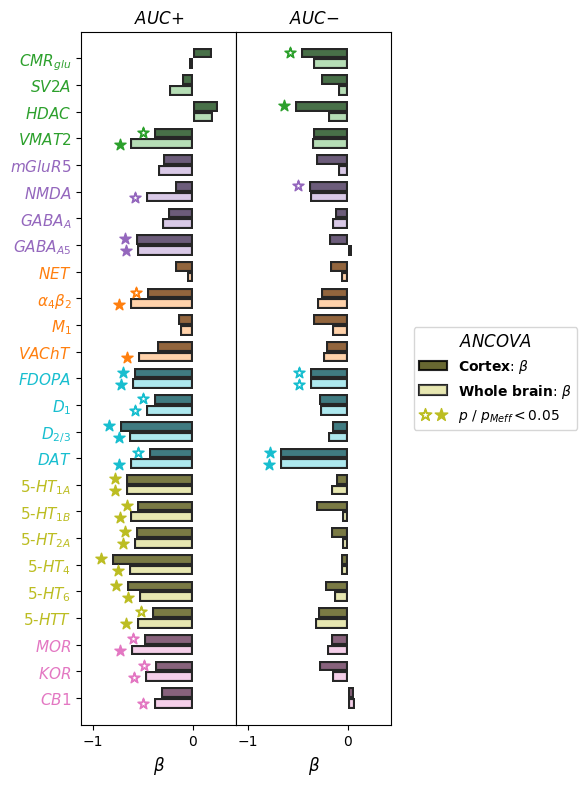

In [14]:
def plot_clinic_overview(ax=None, save_path=None, bar_alpha=0.5, sample="all",
                         legend=True, legend_loc="center left", legend_bbox=None, legend_ncol=1):
    parc_cx = "Schaefer200"
    parc_wb = "Schaefer200Subcortical"
        
    def plot_bars(metric, ax, x_range, bar_alpha=bar_alpha, title=None, sample=sample):
        df = (
            comp_ep
            .loc[:, metric, sample, "dx", REF_NAMES_PET].copy()
            .droplevel(["metric", "sample", "between"])
        )
        df[[ "beta", "np2", "p", "pmeff"]] = df[["beta", "np2", "p", "pmeff"]].astype(float)
        if title is None:
            title = f"${metric.title()}$"
         
        # bars
        (
            so.Plot(data=df.reset_index())
            .add(so.Bar(alpha=bar_alpha + 0.2, edgewidth=0), so.Dodge(by=["group"]), 
                 x="beta", y="dv", color="dv", group="parc", legend=False)
            .add(so.Bar(edgecolor="k", alpha=bar_alpha, edgewidth=1.5), so.Dodge(by=["group"]), 
                 x="beta", y="dv", color="parc", group="parc", legend=False)
            .scale(color={parc_cx: "k", parc_wb: "w"} | REF_COLORS_BY_MAP)
            .limit(x=x_range)
            .on(ax)
            .plot()
        )
    
        # significance
        x_offset = np.diff(ax.get_xlim()) * 0.07
        for l in ax.get_yticklabels():
            m = l.get_text()
            
            # iterate cortex/whole-brain
            if parc_cx in df.index.get_level_values("parc") and parc_wb in df.index.get_level_values("parc"):
                iterator = [(parc_cx, -0.25), (parc_wb, 0.2)]
            elif parc_cx in df.index.get_level_values("parc"):
                iterator = [(parc_cx, 0)]
            else:
                iterator = [(parc_wb, 0)]
            for parc, y_offset in iterator:
                
                # effect-specific p values
                p = df.loc[(parc, m), "p"]
                pmeff = df.loc[(parc, m), "pmeff"]
                beta = df.loc[(parc, m), "beta"]
                if p < 0.05:
                    x = (beta + x_offset) if beta > 0 else (beta - x_offset)
                    y = l.get_position()[1] + y_offset
                    ax.plot(x, y, marker="$★$" if pmeff < 0.05 else "$☆$", markersize=8, 
                            linestyle="None", color=REF_COLORS_BY_MAP[m])
        
        # layout
        ax.set_title(title, size=12)
        ax.set_xlim(x_range)
        ax.set_xlabel(f"$\\beta$", size=12)
        ax.set_ylim(len(REF_NAMES_PET), -1)
        ax.set_ylabel("")

    # PLOT
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4, 9), sharey=False, sharex=False)
    
    # plot bars
    ax.set_axis_off()
    ax_orig = ax.inset_axes((0, 0, 0.5, 1))
    ax_inv = ax.inset_axes((0.5, 0, 0.5, 1))
    
    # range for x-axis
    x_range = comp_ep.loc[:, :, sample, :]["beta"].quantile([0,1]).values
    x_range = x_range[0] - (x_range[1] - x_range[0]) * 0.05, x_range[1] + (x_range[1] - x_range[0]) * 0
    
    # original
    plot_bars("original", ax_orig, x_range=x_range, title="$AUC\t{+}$")
    
    # inverted
    plot_bars("inverted", ax_inv, x_range=x_range, title="$AUC\t{-}$")
    
    ax_orig.set_yticks(ax_orig.get_yticks(), labels=ax_orig.get_yticklabels(), fontsize=11)
    ax_inv.set_yticks([])
    for l in ax_orig.get_yticklabels():
        l.set_color(REF_COLORS_BY_MAP[l.get_text()])
    ax_orig.set_yticks(ax_orig.get_yticks(), labels=[REF_MATH_NAMES[m] for m in REF_NAMES_PET])
    ax_inv.set_yticklabels([])
    
    # legend
    legend_kws = {"title_fontproperties": {'weight':'semibold', "size": 12}, "loc": "center left"}
    handle_bar_color = plt.Rectangle((0, 0), 1, 1, color=REF_COLORS_BY_MAP["5HT4"], lw=1.5, ec="k", alpha=bar_alpha + 0.2)
    handle_bar_black = plt.Rectangle((0, 0), 1, 1, color="k", lw=1.5, ec="k", alpha=bar_alpha)
    handle_bar_white = plt.Rectangle((0, 0), 1, 1, color="w", lw=1.5, ec="k", alpha=bar_alpha)
    handle_stars = (plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["5HT4"], marker="$☆$", markersize=9, linestyle="None"),
                    plt.Line2D([0], [0], color=REF_COLORS_BY_MAP["5HT4"], marker="$★$", markersize=9, linestyle="None"))
    
    # legend
    if legend:
        handles_dict = {
            f"$\\bf{{Cortex}}$: $\\beta$": (handle_bar_color, handle_bar_black),
            f"$\\bf{{Whole\ brain}}$: $\\beta$": (handle_bar_color, handle_bar_white),
            "$p\ /\ p_{Meff} < 0.05$": handle_stars
        }
        ax.legend(
            list(handles_dict.values()), list(handles_dict.keys()), 
            title="$ANCOVA$", title_fontproperties={'weight':'semibold', "size": 12}, 
            loc=legend_loc, bbox_to_anchor=(1.05, 0.5) if legend_bbox is None else legend_bbox,
            ncol=legend_ncol, handler_map={handle_stars: mpl.legend_handler.HandlerTuple(ndivide=None)}
        )
    
    # save
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        
    # return subplots
    return ax_orig, ax_inv

plot_clinic_overview(sample="all")

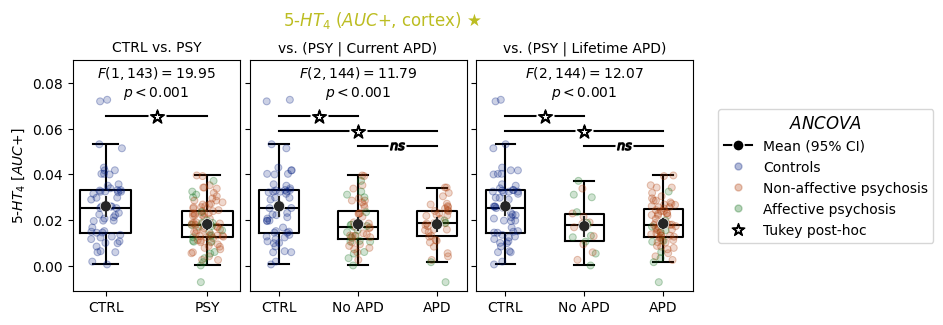

In [ ]:
def plot_clinic_points(metric, m, parc="Schaefer200", ax=None, 
                       legend=False, legend_loc="center left", legend_bbox=None, legend_ncol=1,
                       ylim=None, bracket_y_offset=1.1):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    
    # get data 
    df = (
        df_ep
        .loc[(parc, metric, slice(None)), [m, "dx", "dx_apd_current", "dx_apd_lifetime", "dx_sub"]]
        .reset_index()
    )
    #display(df)
    
    stats = (   
        comp_ep
        .loc[parc, metric, "all", :, m]
    )
    #display(stats)
    
    axes = [
        ax.inset_axes((0, 0, 0.27, 1)),
        ax.inset_axes((0.285, 0, 0.35, 1)),
        ax.inset_axes((0.65, 0, 0.35, 1)),
    ]
    ax.set_axis_off()
    for title, df_dx, df_stats, ax1 in [
        ("CTRL vs. PSY", df, stats.loc["dx", :], axes[0]),
        ("vs. (PSY | Current APD)", df.assign(dx=df.dx_apd_current), stats.loc["dx_apd_current", :], axes[1]),
        ("vs. (PSY | Lifetime APD)", df.assign(dx=df.dx_apd_lifetime), stats.loc["dx_apd_lifetime", :], axes[2]),
    ]:
        
        # x categories
        if "CTRL" not in df_dx["dx"].unique():
            df_dx["dx"] = pd.Categorical(df_dx["dx"], categories=["PSY_noAPD", "PSY_APD"], ordered=True)
        
        # plot
        (
            so.Plot(df_dx, x="dx", y=m)
            .add(so.Dots(marker="o", alpha=0.3, pointsize=5), so.Jitter(width=0.4), color="dx_sub", legend=False)
            .add(so.Range(color="k", linewidth=1.5), so.Est(errorbar=("ci", 95)))
            .add(so.Dot(color="k", marker="o", pointsize=8, edgecolor="w"), so.Agg("mean"))
            .scale(color=so.Nominal("dark"))
            .label(x="", y=f"$AUC$", size=12)
            .on(ax1)
            .plot()
        )
        sn.boxplot(
            df_dx,
            x="dx",
            y=m,
            dodge=True,
            width=0.5,
            color="k",
            fill=False,
            fliersize=0,
            ax=ax1,
            zorder=-10
        )
        
        # labels
        ax1.set_xlabel("")
        ax1.set_title(title, fontsize=10)
        F_str = f"$F({df_stats['df_model']:.0f}, {df_stats['df_resid']:.0f})={df_stats['F']:.02f}$"
        p_str = f"$p={df_stats['p']:.03f}$" if df_stats['p'] >= 0.001 else f"$p<0.001$"
        ax1.annotate(f"{F_str}\n{p_str}", xy=(0.5, 0.98), xycoords="axes fraction", ha="center", va="top", fontsize=10)
        
        # function to plots significance brackets and stars
        def plot_significance_bracket(ax, x1, x2, y, p, bracket_y_offset=bracket_y_offset, sig=True):
            ax.plot([x1, x2], [y * bracket_y_offset] * 2, color="k", linewidth=1.5)
            ax1.plot(np.mean([x1, x2]), [y * bracket_y_offset], linestyle="none", marker="o", markersize=12, color="w")
            ax1.plot(np.mean([x1, x2]), [y * bracket_y_offset], linestyle="none", marker=f"${'☆' if sig else 'ns'}$", markersize=10, color="k")
            
        # two groups comparison
        if title == "CTRL vs. PSY":
            
            # y axis
            ax1.set_ylabel(f"{REF_MATH_NAMES[m]} $[AUC\t{{{'+' if metric == 'original' else '-'}}}]$", fontsize=10)
            if ylim is not None:
                ax1.set_ylim(*ylim)
                
            # x axis
            ax1.set_xticks(ax1.get_xticks(), labels=["CTRL", "PSY"], fontsize=10)
                
            # text and bracket
            plot_significance_bracket(ax1, 0, 1, df_dx[m].max(), stats.loc['dx', 'p'], bracket_y_offset=bracket_y_offset)

        else:
            
            # y ayis
            ax1.set_ylabel("")
            ax1.set_ylim(axes[0].get_ylim())
            ax1.set_yticklabels([])
            
            # x axis
            ax1.set_xticks(ax1.get_xticks(), labels=["CTRL", "No APD", "APD"], fontsize=10)
            
            # text and bracket
            plot_significance_bracket(ax1, 0, 1, df_dx[m].max(), stats.loc['dx', 'p'],
                                      sig="CTRL > PSY_noAPD" in df_stats.posthoc)
            plot_significance_bracket(ax1, 0, 2, df_dx[m].max() * 0.9, stats.loc['dx', 'p'],
                                      sig="CTRL > PSY_APD" in df_stats.posthoc)
            plot_significance_bracket(ax1, 1, 2, df_dx[m].max() * 0.8, stats.loc['dx', 'p'],
                                      sig="PSY_noAPD > PSY_APD" in df_stats.posthoc or "PSY_APD > PSY_noAPD" in df_stats.posthoc)

    ax.set_title(
        f"{REF_MATH_NAMES[m]} $(AUC\t{{{'+' if metric == 'original' else '-'}}}$, {'cortex' if not 'Subcortical' in parc else 'whole-brain'}$)$ ★", 
        color=REF_COLORS_BY_MAP[m], fontsize=12, pad=25)
    
    if legend:
        handles_dict = {
            "Mean (95% CI)": mpl.lines.Line2D([0], [0], color="k", marker="o", markersize=8, markeredgecolor="w"),
            "Controls": mpl.lines.Line2D([0], [0], color=sn.color_palette("dark", 3)[0], marker="o", linewidth=0, markersize=5, alpha=0.3),
            "Non-affective psychosis": mpl.lines.Line2D([0], [0], color=sn.color_palette("dark", 3)[1], marker="o", linewidth=0, markersize=5, alpha=0.3),
            "Affective psychosis": mpl.lines.Line2D([0], [0], color=sn.color_palette("dark", 3)[2], marker="o", linewidth=0, markersize=5, alpha=0.3),
            "Tukey post-hoc": mpl.lines.Line2D([0], [0], linestyle="none", marker="$☆$", markersize=9, color="k"),
        }
        ax.legend(handles_dict.values(), handles_dict.keys(), loc=legend_loc, 
                  title="$ANCOVA$", title_fontproperties={'weight':'semibold', "size": 12}, 
                  bbox_to_anchor=(1.03, 0.5) if legend_bbox is None else legend_bbox, ncol=legend_ncol)
        
        
plot_clinic_points("original", "5HT4", legend=True, bracket_y_offset=0.9, ylim=(None, 0.09))

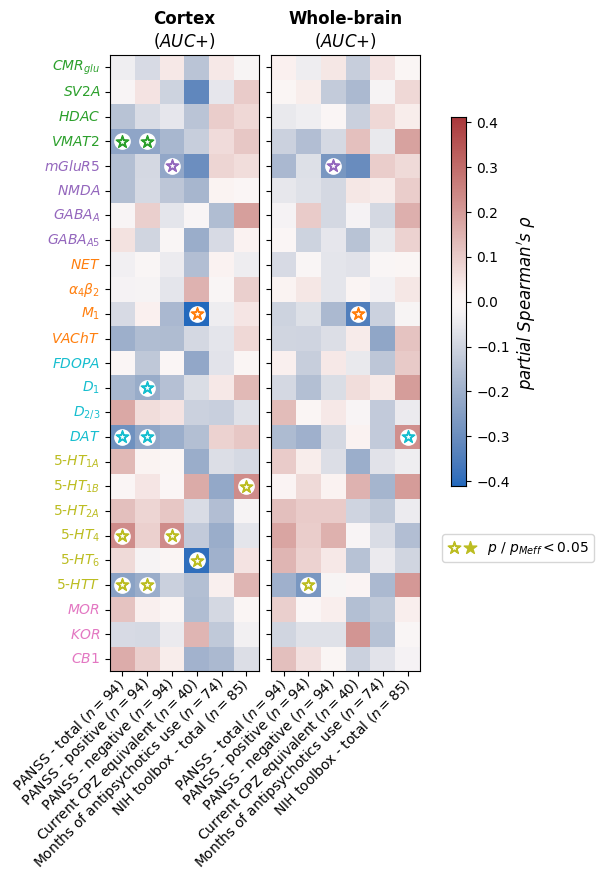

In [16]:
def plot_clinic_assoc_pattern(metric, rho, parc="Schaefer200", ax=None, cbar=True, cax=None):
    
    assert metric in ["original", "inverted"], "Only 'original' and 'inverted' metrics supported"
    assert rho in ["rho", "rho_partial"], "Only 'rho' and 'rho_partial' supported"
    if rho == "rho":
        p = "p"
        pmeff = "pmeff"
    else:        
        p = "p_partial"
        pmeff = "pmeff_partial"
    assert parc in ["Schaefer100", "Schaefer200", "Schaefer400"], "Only Schaefer parcs supported"
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))
    ax_cx = ax.inset_axes((0, 0, 0.48, 1))
    ax_wb = ax.inset_axes((0.52, 0, 0.48, 1))
    ax.set_axis_off()
    
    if cax is None:
        cax = ax.inset_axes((1.1, 0.3, 0.05, 0.6))
    
    # data
    df_cx = assoc_ep.loc[parc, metric, :, :, :][[rho, p, pmeff]].unstack(level="map", sort=False).T
    df_wb = assoc_ep.loc[parc + "Subcortical", metric, :, :, :][[rho, p, pmeff]].unstack(level="map", sort=False).T
    vmax = max(df_cx.loc[rho].abs().max().max(), df_wb.loc[rho].abs().max().max())
    
    # plot
    for df, ax_this, title in [(df_cx, ax_cx, "Cortex"), (df_wb, ax_wb, "Whole-brain")]:
        sn.heatmap(
            df.loc[rho], 
            center=0, 
            ax=ax_this,
            cbar=cbar,
            cbar_ax=cax,
            cmap="vlag",
            vmin=-vmax,
            vmax=vmax,
        )
        sn.despine(ax=ax_this, top=False, right=False, left=False, bottom=False)
                
        # plot significance
        for cat, maps in REF_GROUPS_PET.items():
            # y positions
            y = [l.get_position()[1] for l in ax_this.get_yticklabels() if l.get_text() in maps]
            # plot markers
            for y_pos in y:
                for x_pos in range(len(ax_this.get_xticklabels())):
                    if df.loc[p].iloc[int(y_pos), x_pos] < 0.05:
                        ax_this.plot(x_pos+0.5, y_pos, marker="o", markersize=11, color="w")
                        ax_this.plot(
                            x_pos+0.5, y_pos-0.025, 
                            marker="$★$" if df.loc[pmeff].iloc[int(y_pos), x_pos] < 0.05 else "$☆$", 
                            markersize=9, color=REF_COLORS_BY_MAP[maps[0]]
                        )
                          
        # labels
        ax_this.set_title(f"{title}\n$(AUC\t{{{'+' if metric == 'original' else '-'}}})$", weight="bold", fontsize=12)
        ax_this.set_xlabel("")
        ax_this.set_ylabel("")
        if title == "Cortex":
            for l in ax_this.get_yticklabels():
                l.set_color(REF_COLORS_BY_MAP[l.get_text()])
            ax_this.set_yticklabels([REF_MATH_NAMES[l.get_text()] for l in ax_this.get_yticklabels()], fontsize=10)
        else:
            ax_this.set_yticklabels([])
        x_labels = df.columns
        x_label_dict = {
            "panss_total": "PANSS - total",
            "panss_pos": "PANSS - positive",
            "panss_neg": "PANSS - negative",
            "apd_chlor_equiv": "Current CPZ equivalent",
            "apd_exp_months": "Months of antipsychotics use",
            "nih_totalcogcomp_unadjusted": "NIH toolbox - total"
        }
        x_labels = [f"{x_label_dict[l[0]]} $(n={l[1]})$" for l in x_labels]
        ax_this.set_xticklabels(x_labels, fontsize=10, rotation=45, rotation_mode="anchor", ha="right", va="center")

    # cax
    sn.despine(ax=cax, top=False, right=False, left=False, bottom=False)
    cax.set_ylabel("${partial}Spearman's\ \\rho$".format(partial='partial\ ' if rho == 'rho_partial' else ''), fontsize=12)

    # legend
    ax.legend(
        labels=["$p\ /\ p_{Meff} < 0.05$"],
        handles=[(mpl.lines.Line2D([0], [0], linestyle="none", marker="$☆$", markersize=9, color=REF_COLORS_BY_MAP["5HT4"]), 
                  mpl.lines.Line2D([0], [0], linestyle="none", marker="$★$", markersize=9, color=REF_COLORS_BY_MAP["5HT4"]))
        ],
        loc="center left",
        bbox_to_anchor=(1.05, 0.2),
        fontsize=10,
        handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)}
    )
    
plot_clinic_assoc_pattern("original", "rho_partial", parc="Schaefer200")

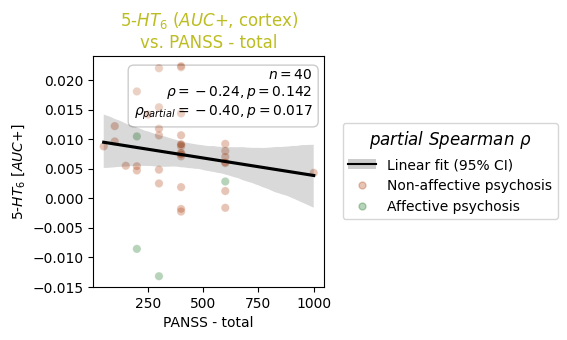

In [17]:
def plot_clinic_assoc_scatter(dv, m, metric, parc="Schaefer200",
                              xlabel="", ax=None, rho=True, rho_partial=True,
                              legend=True, legend_loc="center left", legend_bbox=None, legend_ncol=1,
                              annot_loc="upper right"):
    
    assert metric in ["original", "inverted"], "Only 'original' and 'inverted' metrics supported"
    assert parc in ["Schaefer100", "Schaefer200", "Schaefer400"], "Only Schaefer parcs supported"
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_box_aspect(1)

    # data
    df_stats = assoc_ep.loc[parc, metric, dv, :, m]
    assert df_stats.shape[0] == 1, "Multiple rows found for the given parameters"
    df_stats = df_stats.iloc[0]
    df = df_ep.loc[parc, metric, :]
    df = df[df.dx == "PSY"].copy()
    if "apd_" in dv:
        df = df[df[dv] > 0]
    
    # plot
    sn.scatterplot(
        data=df,
        x=dv,
        y=m,
        hue="dx_aff",
        alpha=0.3,
        palette=[sn.color_palette("dark", 3)[1], sn.color_palette("dark", 3)[2]],
        ax=ax
    )
    sn.regplot(
        data=df,
        x=dv,
        y=m,
        scatter=False,
        color="k",
        ax=ax,
    )
    
    # annotation
    s = f"$n = {df.shape[0]}$"
    if rho:
        s += f"\n$\\rho = {df_stats['rho']:.2f}, p = {df_stats['p']:.3f}$"
    if rho_partial:
        s += f"\n$\\rho_{{partial}} = {df_stats['rho_partial']:.2f}, p = {df_stats['p_partial']:.3f}$"
    ax.annotate(
        s,
        xy={"upper left": (0.05, 0.95), "upper right": (0.95, 0.95), "lower left": (0.05, 0.05), "lower right": (0.95, 0.05)}[annot_loc],
        xycoords="axes fraction",
        ha="right" if annot_loc in ["upper right", "lower right"] else "left",
        va="bottom" if annot_loc in ["lower left", "lower right"] else "top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", edgecolor="k", facecolor="w", alpha=0.2)
    )

    
    # labels
    ax.set_ylabel(f"{REF_MATH_NAMES[m]} $[AUC\t{{{'+' if metric == 'original' else '-'}}}]$", fontsize=10)
    ax.set_xlabel(xlabel if xlabel else dv, fontsize=10)
    ax.set_title(
        f"{REF_MATH_NAMES[m]} $(AUC\t{{{'+' if metric == 'original' else '-'}}}$, {'cortex' if not 'Subcortical' in parc else 'whole-brain'}$)$\n"
        f"vs. {xlabel}", 
        color=REF_COLORS_BY_MAP[m], fontsize=12)
    
    # legend
    if legend:
        line_handle = (mpl.lines.Line2D([0], [0], color="k", marker="none"),
                       plt.Rectangle((0, 0), 1, 1, color="k", ec="none", alpha=0.2))
        handles_dict = {
            "Linear fit (95% CI)": line_handle,
            "Non-affective psychosis": mpl.lines.Line2D([0], [0], color=sn.color_palette("dark", 3)[1], marker="o", linewidth=0, markersize=5, alpha=0.3),
            "Affective psychosis": mpl.lines.Line2D([0], [0], color=sn.color_palette("dark", 3)[2], marker="o", linewidth=0, markersize=5, alpha=0.3),
        }
        ax.legend(handles_dict.values(), handles_dict.keys(), loc=legend_loc, fontsize=10,
                  title=("$partial$ " if rho_partial else "") + f"$Spearman\ \\rho$", 
                  title_fontproperties={'weight':'semibold', "size": 12}, 
                  bbox_to_anchor=(1.05, 0.5) if legend_bbox is None else legend_bbox, ncol=legend_ncol)
    else:
        ax.legend().set_visible(False)
        
    
plot_clinic_assoc_scatter("apd_chlor_equiv", "5HT6", "original", xlabel="PANSS - total", parc="Schaefer200")

### Main plot

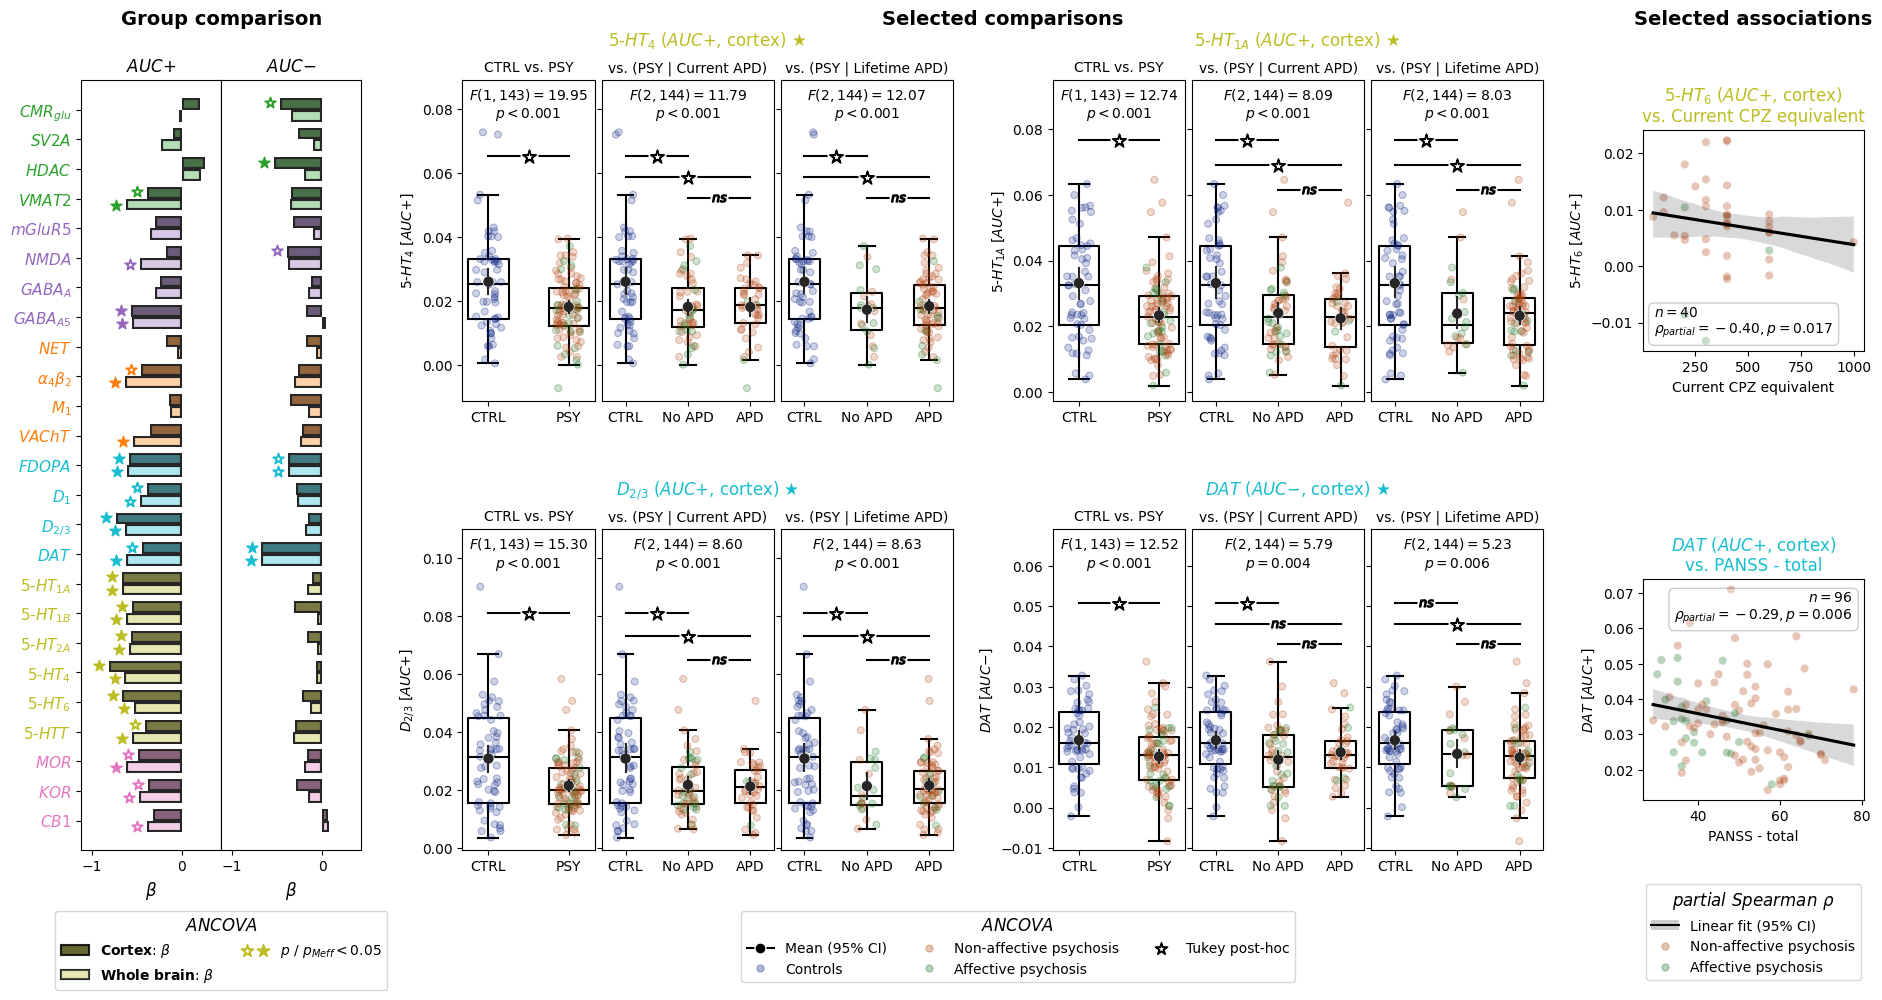

In [18]:
fig = plt.figure(figsize=(23, 10))
gs = plt.GridSpec(1, 2, wspace=0.12, width_ratios=[1, 5])

# effect size overview
ax = fig.add_subplot(gs[0, 0])
ax.set_title("Group comparison", fontsize=14, weight="bold", pad=40)
plot_clinic_overview(ax=ax, legend_loc="upper center", legend_bbox=(0.5, -0.07), legend_ncol=2)

# strongest effects
gs_sub = gs[0, 1:].subgridspec(2, 3, wspace=0.25, hspace=0.4, height_ratios=[1, 1], width_ratios=[1, 1, 0.45])
axes = [fig.add_subplot(gs_sub[0, 0]), fig.add_subplot(gs_sub[0, 1]), fig.add_subplot(gs_sub[1, 0]), fig.add_subplot(gs_sub[1, 1])]
tmp = fig.add_subplot(gs_sub[0, 0:2])
tmp.set_axis_off()
tmp.set_title("Selected comparisons", fontsize=14, weight="bold", pad=40)
for i, (m, metric, y_max, y_offset) in enumerate(
    [("5HT4", "original", 0.089, 0.9), ("5HT1a", "original", 0.095, 0.8), ("D23", "original", 0.11, 0.9), ("DAT", "inverted", 0.069, 1.4)]
):
    ax = axes[i]
    plot_clinic_points(metric, m, ax=ax, legend=i==3, legend_loc="center left", legend_bbox=(-0.65, -0.3), legend_ncol=3,
                       bracket_y_offset=y_offset, ylim=(None, y_max))
        
# associations
axes = [fig.add_subplot(gs_sub[0, 2]), fig.add_subplot(gs_sub[1, 2])]
tmp = fig.add_subplot(gs_sub[0, 2])
tmp.set_axis_off()
tmp.set_title("Selected associations", fontsize=14, weight="bold", pad=40)
plot_clinic_assoc_scatter("apd_chlor_equiv", "5HT6", "original", xlabel="Current CPZ equivalent", parc="Schaefer200", ax=axes[0], 
                          legend=False, annot_loc="lower left", 
                          rho=False, rho_partial=True)
plot_clinic_assoc_scatter("panss_total", "DAT", "original", xlabel="PANSS - total", parc="Schaefer200", ax=axes[1], 
                          legend=True, legend_loc="upper center", legend_bbox=(0.5, -0.35),
                          rho=False, rho_partial=True)

# save
fig.savefig(wd / "plots" / "clinic" / "clinic_parc-Schaefer200.pdf", bbox_inches="tight")

### Combined association plot

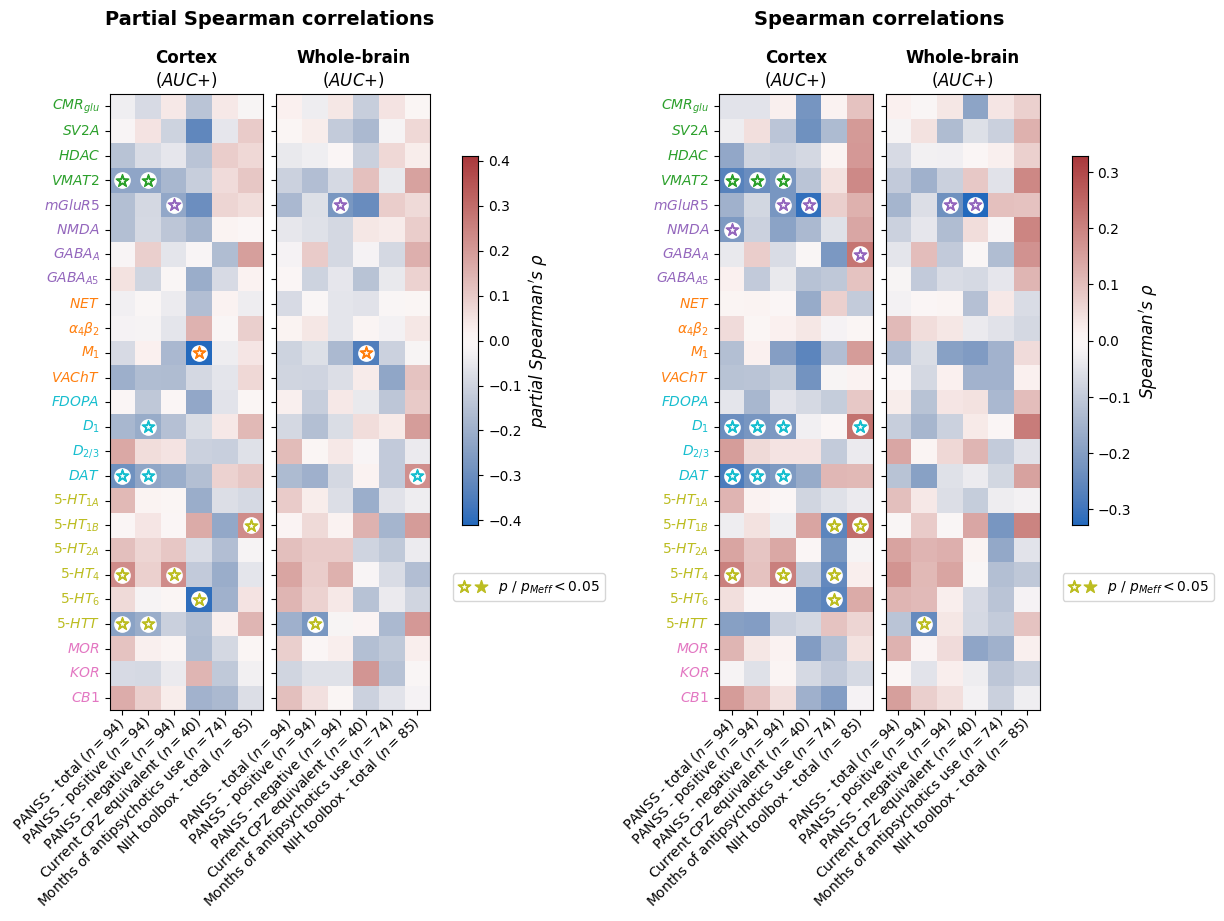

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={"wspace": 0.9})
for i, rho in enumerate(["rho_partial", "rho"]):
    axes[i].set_title(f"{'Partial ' if 'partial' in rho else ''}Spearman correlations", fontsize=14, weight="bold", pad=50)
    plot_clinic_assoc_pattern("original", rho, ax=axes[i])
fig.savefig(wd / "plots" / "clinic" / "clinicassoc_parc-Schaefer200.pdf", bbox_inches="tight")